<a href="https://colab.research.google.com/github/YakshilP/AEO_Forecasting/blob/main/AEO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import requests
import pandas as pd
import numpy as np

# AEO's CIK (Central Index Key) — every SEC filer has one; this is AEO's, zero-padded to 10 digits
cik = "0000919012"

# SEC requires a real identifying User-Agent or it rejects the request with a 403 error
headers = {
    "User-Agent": "Yakshil Patel yakshilpatel7@gmail.com"
}

# This endpoint returns every historical value AEO has ever reported for ONE accounting concept —
# here, "InventoryNet" (their merchandise inventory line item)
url = f"https://data.sec.gov/api/xbrl/companyconcept/CIK{cik}/us-gaap/InventoryNet.json"

response = requests.get(url, headers=headers)
data = response.json()

print(response.status_code)   # 200 = success, 403 = blocked (bad User-Agent), 404 = wrong URL/CIK
print(data.keys())            # shows the top-level shape of what came back

200
dict_keys(['cik', 'taxonomy', 'tag', 'label', 'description', 'entityName', 'units'])


In [17]:
# Pull just the list of reported facts out of the nested JSON
facts = data["units"]["USD"]

# pandas builds a DataFrame directly from a list of dicts — each dict becomes a row,
# each shared key becomes a column
inv_df = pd.DataFrame(facts)

print(inv_df.shape)      # (rows, columns)
print(inv_df.head(10))   # first 10 rows, so you can see the real structure

(179, 8)
          end        val                  accn    fy  fp  form       filed  \
0  2009-08-01  352819000  0000950123-10-080878  2010  Q2  10-Q  2010-08-25   
1  2009-10-31  425415000  0000950123-10-107439  2010  Q3  10-Q  2010-11-19   
2  2010-01-30  326454000  0000950123-10-080878  2010  Q2  10-Q  2010-08-25   
3  2010-01-30  326454000  0000950123-10-107439  2010  Q3  10-Q  2010-11-19   
4  2010-01-30  326454000  0000950123-11-024788  2010  FY  10-K  2011-03-11   
5  2010-05-01  326417000  0000950123-11-054440  2011  Q1  10-Q  2011-05-26   
6  2010-07-31  349091000  0000950123-10-080878  2010  Q2  10-Q  2010-08-25   
7  2010-07-31  349091000  0001193125-11-232426  2011  Q2  10-Q  2011-08-25   
8  2010-10-30  409509000  0000950123-10-107439  2010  Q3  10-Q  2010-11-19   
9  2010-10-30  409509000  0001193125-11-326066  2011  Q3  10-Q  2011-11-30   

       frame  
0  CY2009Q2I  
1  CY2009Q3I  
2        NaN  
3        NaN  
4  CY2009Q4I  
5  CY2010Q1I  
6        NaN  
7  CY2010Q2I

In [18]:
def get_sec_concept(cik, concept, headers):
    """Pulls one financial concept's full history from SEC EDGAR, live."""
    url = f"https://data.sec.gov/api/xbrl/companyconcept/CIK{cik}/us-gaap/{concept}.json"
    r = requests.get(url, headers=headers)
    r.raise_for_status()  # stops immediately with a clear error if SEC rejects the request
    facts = r.json()["units"]["USD"]
    return pd.DataFrame(facts)

def clean_annual(df):
    """Keeps only clean, unique, chronologically-sorted 10-K annual figures."""
    annual = df[df["form"] == "10-K"].copy()          # boolean filter: keep only annual filings
    annual = annual.drop_duplicates(subset=["end", "val"])  # drop exact repeat rows
    annual = annual.sort_values("end").reset_index(drop=True)
    return annual[["end", "val", "fy"]]

inventory_raw = get_sec_concept(cik, "InventoryNet", headers)
cogs_raw = get_sec_concept(cik, "CostOfGoodsAndServicesSold", headers)

inventory_clean = clean_annual(inventory_raw)
cogs_clean = clean_annual(cogs_raw)

print(inventory_clean.tail(6))
print(cogs_clean.tail(6))

           end        val    fy
12  2021-01-30  405445000  2020
13  2022-01-29  553458000  2021
14  2023-01-28  585083000  2022
15  2024-02-03  640662000  2023
16  2025-02-01  636655000  2024
17  2026-01-31  701966000  2025
          end         val    fy
4  2021-01-30  2610966000  2020
5  2022-01-29  3018995000  2021
6  2023-01-28  3244585000  2022
7  2024-02-03  3237192000  2023
8  2025-02-01  3239719000  2024
9  2026-01-31  3521915000  2025


In [19]:
# Merge the two DataFrames where their 'end' dates match — this lines up
# each year's inventory figure with that same year's cost of goods
merged = pd.merge(
    inventory_clean,
    cogs_clean,
    on="end",                          # the shared column to match rows on
    suffixes=("_inventory", "_cogs")   # since both tables have a "val" and "fy" column,
                                        # this renames them so they don't collide
)

# Days Inventory Outstanding — how many days of inventory you're holding, on average
merged["DIO"] = merged["val_inventory"] / merged["val_cogs"] * 365

# Inventory Turnover — how many times inventory is sold/replaced per year
merged["turnover"] = merged["val_cogs"] / merged["val_inventory"]

# Year-over-year inventory growth, as a percentage
merged["inventory_yoy_growth_pct"] = merged["val_inventory"].pct_change() * 100

print(merged[["end", "val_inventory", "val_cogs", "DIO", "turnover", "inventory_yoy_growth_pct"]])

          end  val_inventory    val_cogs        DIO  turnover  \
0  2017-01-28      358446000  2242938000  58.330988  6.257394   
1  2018-02-03      398213000  2425044000  59.936127  6.089816   
2  2019-02-02      424404000  2548082000  60.793750  6.003907   
3  2020-02-01      446278000  2785911000  58.469732  6.242546   
4  2021-01-30      405445000  2610966000  56.679185  6.439754   
5  2022-01-29      553458000  3018995000  66.913715  5.454786   
6  2023-01-28      585083000  3244585000  65.818986  5.545512   
7  2024-02-03      640662000  3237192000  72.235947  5.052886   
8  2025-02-01      636655000  3239719000  71.728158  5.088657   
9  2026-01-31      701966000  3521915000  72.749510  5.017216   

   inventory_yoy_growth_pct  
0                       NaN  
1                 11.094279  
2                  6.577133  
3                  5.154051  
4                 -9.149678  
5                 36.506308  
6                  5.714074  
7                  9.499336  
8             

In [20]:
# Convert 'end' dates into a simple numeric x-axis: years since the first record
# (regression math needs numbers, not date strings)
merged["end"] = pd.to_datetime(merged["end"])
merged["year_num"] = merged["end"].dt.year

x = merged["year_num"].values
y = merged["val_inventory"].values

# Fit a degree-1 (straight line) trend: returns [slope, intercept]
slope, intercept = np.polyfit(x, y, 1)

# Project the next fiscal year-end
next_year = x[-1] + 1
forecast_inventory = slope * next_year + intercept

print(f"Trend: inventory changing by ${slope:,.0f} per year")
print(f"Forecast for FY ending {next_year}: ${forecast_inventory:,.0f}")


Trend: inventory changing by $38,827,224 per year
Forecast for FY ending 2027: $728,610,733


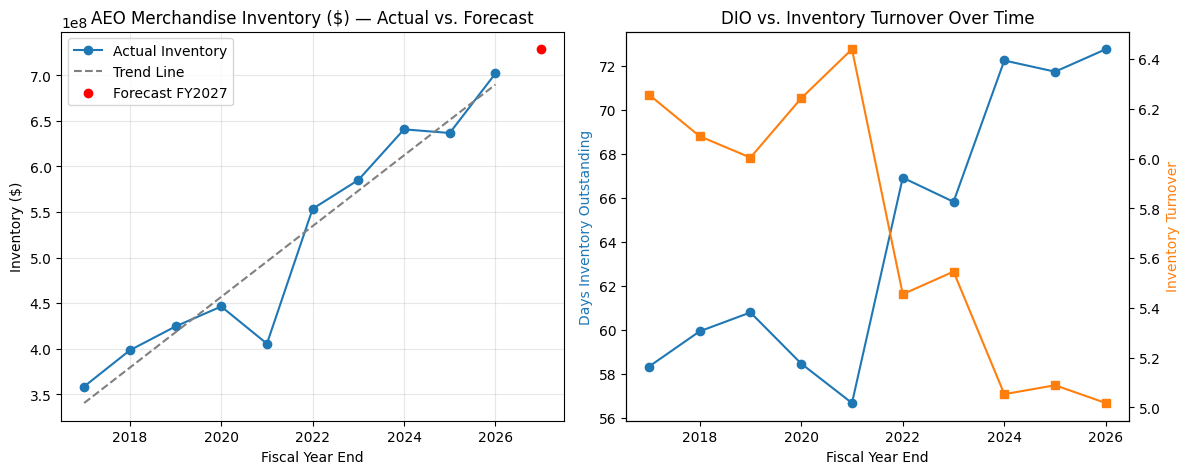

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1: Inventory over time + forecast point
axes[0].plot(merged["year_num"], merged["val_inventory"], marker="o", label="Actual Inventory")
axes[0].plot(x, slope * x + intercept, linestyle="--", color="gray", label="Trend Line")
axes[0].scatter([next_year], [forecast_inventory], color="red", zorder=5, label=f"Forecast FY{next_year}")
axes[0].set_title("AEO Merchandise Inventory ($) — Actual vs. Forecast")
axes[0].set_xlabel("Fiscal Year End")
axes[0].set_ylabel("Inventory ($)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Chart 2: DIO and Turnover trend together
ax2 = axes[1]
ax2.plot(merged["year_num"], merged["DIO"], marker="o", color="tab:blue", label="DIO (days)")
ax2.set_ylabel("Days Inventory Outstanding", color="tab:blue")
ax2.set_xlabel("Fiscal Year End")
ax2.set_title("DIO vs. Inventory Turnover Over Time")

ax3 = ax2.twinx()  # a second y-axis sharing the same x-axis
ax3.plot(merged["year_num"], merged["turnover"], marker="s", color="tab:orange", label="Turnover (x)")
ax3.set_ylabel("Inventory Turnover", color="tab:orange")

plt.tight_layout()
plt.savefig("aeo_inventory_charts.png", dpi=300)  # dpi=300 = print-quality resolution
plt.show()

In [22]:
def fetch_and_clean(cik, concept, headers):
    """Fetch one XBRL concept from SEC EDGAR and return clean annual data."""
    url = f"https://data.sec.gov/api/xbrl/companyconcept/CIK{cik}/us-gaap/{concept}.json"
    r = requests.get(url, headers=headers)
    r.raise_for_status()
    facts = pd.DataFrame(r.json()["units"]["USD"])
    annual = facts[facts["form"] == "10-K"].copy()
    annual = annual.drop_duplicates(subset=["end", "val"])
    annual = annual.sort_values("end").reset_index(drop=True)
    return annual[["end", "val", "fy"]]

def build_metrics_table(inventory_df, cogs_df):
    """Merge inventory + COGS and compute DIO, turnover, YoY growth."""
    merged = pd.merge(inventory_df, cogs_df, on="end", suffixes=("_inventory", "_cogs"))
    merged["end"] = pd.to_datetime(merged["end"])
    merged["year_num"] = merged["end"].dt.year
    merged["DIO"] = merged["val_inventory"] / merged["val_cogs"] * 365
    merged["turnover"] = merged["val_cogs"] / merged["val_inventory"]
    merged["inventory_yoy_growth_pct"] = merged["val_inventory"].pct_change() * 100
    return merged

def forecast_next_year(merged):
    """Fit a linear trend and forecast next fiscal year-end inventory."""
    x = merged["year_num"].values
    y = merged["val_inventory"].values
    slope, intercept = np.polyfit(x, y, 1)
    next_year = x[-1] + 1
    forecast = slope * next_year + intercept
    return next_year, forecast, slope, intercept

# --- Run the whole pipeline ---
cik = "0000919012"
headers = {"User-Agent": "Yakshil Patel yakshilpatel7@gmail.com"}

inventory_clean = fetch_and_clean(cik, "InventoryNet", headers)
cogs_clean = fetch_and_clean(cik, "CostOfGoodsAndServicesSold", headers)
merged = build_metrics_table(inventory_clean, cogs_clean)
next_year, forecast, slope, intercept = forecast_next_year(merged)

print(merged.tail())
print(f"\nForecast FY{next_year}: ${forecast:,.0f}")

         end  val_inventory  fy_inventory    val_cogs  fy_cogs  year_num  \
5 2022-01-29      553458000          2021  3018995000     2021      2022   
6 2023-01-28      585083000          2022  3244585000     2022      2023   
7 2024-02-03      640662000          2023  3237192000     2023      2024   
8 2025-02-01      636655000          2024  3239719000     2024      2025   
9 2026-01-31      701966000          2025  3521915000     2025      2026   

         DIO  turnover  inventory_yoy_growth_pct  
5  66.913715  5.454786                 36.506308  
6  65.818986  5.545512                  5.714074  
7  72.235947  5.052886                  9.499336  
8  71.728158  5.088657                 -0.625447  
9  72.749510  5.017216                 10.258460  

Forecast FY2027: $728,610,733


In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# --- Model A (what we already built): inventory regressed on time alone ---
X_time = merged[["year_num"]]          # sklearn expects a 2D input, even for one column
y = merged["val_inventory"]

model_time = LinearRegression()
model_time.fit(X_time, y)
pred_time = model_time.predict(X_time)
r2_time = r2_score(y, pred_time)

# --- Model B (the refinement): inventory regressed on COGS instead of time ---
X_cogs = merged[["val_cogs"]]

model_cogs = LinearRegression()
model_cogs.fit(X_cogs, y)
pred_cogs = model_cogs.predict(X_cogs)
r2_cogs = r2_score(y, pred_cogs)

print(f"R² using time as predictor: {r2_time:.4f}")
print(f"R² using COGS as predictor: {r2_cogs:.4f}")

R² using time as predictor: 0.9212
R² using COGS as predictor: 0.9579


In [24]:
# Forecast next year's COGS using the same time-based approach as before
cogs_slope, cogs_intercept = np.polyfit(merged["year_num"], merged["val_cogs"], 1)
next_year_cogs = cogs_slope * next_year + cogs_intercept

# Now use the COGS-based inventory model to forecast inventory from that projected COGS
forecast_inventory_v2 = model_cogs.predict([[next_year_cogs]])[0]

print(f"Projected FY{next_year} COGS: ${next_year_cogs:,.0f}")
print(f"Refined inventory forecast (via COGS regression): ${forecast_inventory_v2:,.0f}")

Projected FY2027 COGS: $3,635,638,667
Refined inventory forecast (via COGS regression): $726,117,598


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [25]:
# Wrap the prediction input in a DataFrame with the SAME column name used in training
forecast_inventory_v2 = model_cogs.predict(pd.DataFrame({"val_cogs": [next_year_cogs]}))[0]


In [26]:
# Flag the disruption years so we can compare with/without them, not just delete blindly
merged["is_disruption_era"] = merged["year_num"].between(2021, 2022)

# Split into two views: the full dataset (already have this) and a "normal years only" subset
normal_years = merged[~merged["is_disruption_era"]].copy()  # ~ means "NOT" — flips True/False

print(f"Full dataset: {len(merged)} years")
print(f"Normal-years-only dataset: {len(normal_years)} years")

# Refit both models (time-based and COGS-based) using ONLY the normal years
X_time_normal = normal_years[["year_num"]]
X_cogs_normal = normal_years[["val_cogs"]]
y_normal = normal_years["val_inventory"]

model_time_normal = LinearRegression().fit(X_time_normal, y_normal)
model_cogs_normal = LinearRegression().fit(X_cogs_normal, y_normal)

r2_time_normal = r2_score(y_normal, model_time_normal.predict(X_time_normal))
r2_cogs_normal = r2_score(y_normal, model_cogs_normal.predict(X_cogs_normal))

print(f"\nR² (time) — full data:    {r2_time:.4f}")
print(f"R² (time) — normal years: {r2_time_normal:.4f}")
print(f"R² (COGS) — full data:    {r2_cogs:.4f}")
print(f"R² (COGS) — normal years: {r2_cogs_normal:.4f}")

Full dataset: 10 years
Normal-years-only dataset: 8 years

R² (time) — full data:    0.9212
R² (time) — normal years: 0.9878
R² (COGS) — full data:    0.9579
R² (COGS) — normal years: 0.9627


In [27]:
# Project COGS forward using only the normal-years trend
cogs_slope_n, cogs_intercept_n = np.polyfit(normal_years["year_num"], normal_years["val_cogs"], 1)
next_year_cogs_normal = cogs_slope_n * next_year + cogs_intercept_n

forecast_normal = model_cogs_normal.predict(
    pd.DataFrame({"val_cogs": [next_year_cogs_normal]})
)[0]

print(f"\nForecast FY{next_year} (full data, COGS model):     ${forecast_inventory_v2:,.0f}")
print(f"Forecast FY{next_year} (normal years only, COGS model): ${forecast_normal:,.0f}")


Forecast FY2027 (full data, COGS model):     $726,117,598
Forecast FY2027 (normal years only, COGS model): $727,873,799


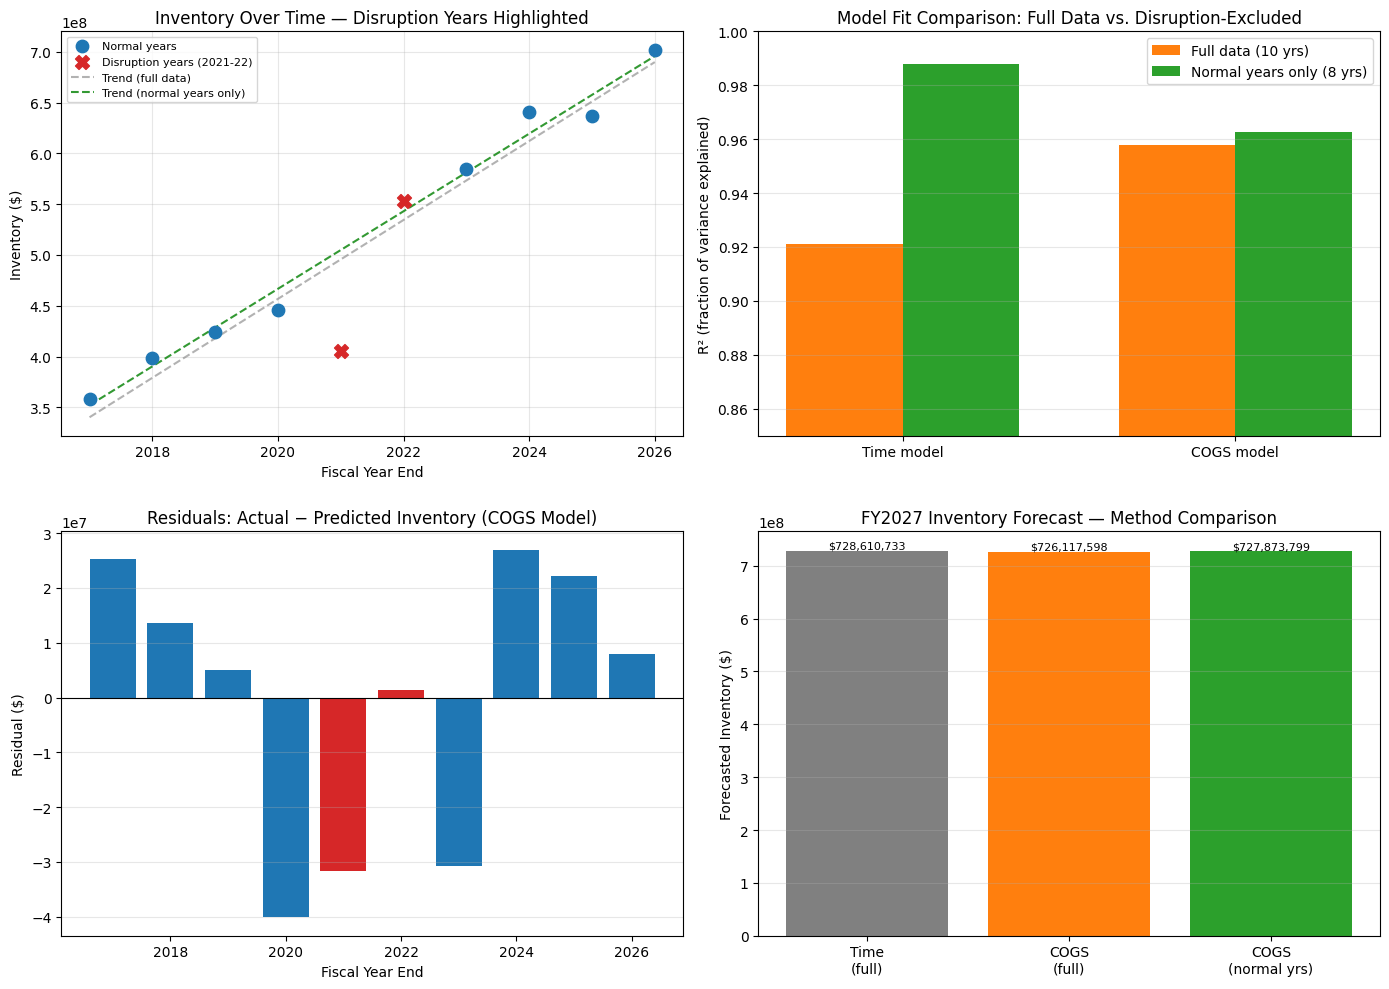

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Panel 1: Inventory over time, disruption years highlighted, both trend lines ---
ax = axes[0, 0]
normal_pts = merged[~merged["is_disruption_era"]]
disruption_pts = merged[merged["is_disruption_era"]]

ax.scatter(normal_pts["year_num"], normal_pts["val_inventory"], color="tab:blue", s=80, zorder=5, label="Normal years")
ax.scatter(disruption_pts["year_num"], disruption_pts["val_inventory"], color="tab:red", s=100, marker="X", zorder=5, label="Disruption years (2021-22)")
ax.plot(merged["year_num"], slope * merged["year_num"] + intercept, "--", color="gray", alpha=0.6, label="Trend (full data)")
ax.plot(normal_years["year_num"], model_time_normal.predict(X_time_normal), "--", color="green", alpha=0.8, label="Trend (normal years only)")
ax.set_title("Inventory Over Time — Disruption Years Highlighted")
ax.set_xlabel("Fiscal Year End")
ax.set_ylabel("Inventory ($)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# --- Panel 2: R² comparison, grouped bar chart ---
ax = axes[0, 1]
labels = ["Time model", "COGS model"]
full_r2 = [r2_time, r2_cogs]
normal_r2 = [r2_time_normal, r2_cogs_normal]
x_pos = np.arange(len(labels))
width = 0.35

ax.bar(x_pos - width/2, full_r2, width, label="Full data (10 yrs)", color="tab:orange")
ax.bar(x_pos + width/2, normal_r2, width, label="Normal years only (8 yrs)", color="tab:green")
ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.set_ylabel("R² (fraction of variance explained)")
ax.set_title("Model Fit Comparison: Full Data vs. Disruption-Excluded")
ax.set_ylim(0.85, 1.0)
ax.legend()
ax.grid(alpha=0.3, axis="y")

# --- Panel 3: Residuals plot for the COGS model (actual - predicted) ---
ax = axes[1, 0]
merged["residual_cogs"] = merged["val_inventory"] - model_cogs.predict(merged[["val_cogs"]])
colors = merged["is_disruption_era"].map({True: "tab:red", False: "tab:blue"})
ax.bar(merged["year_num"], merged["residual_cogs"], color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Residuals: Actual − Predicted Inventory (COGS Model)")
ax.set_xlabel("Fiscal Year End")
ax.set_ylabel("Residual ($)")
ax.grid(alpha=0.3, axis="y")

# --- Panel 4: Forecast comparison across all 4 methods ---
ax = axes[1, 1]
methods = ["Time\n(full)", "COGS\n(full)", "COGS\n(normal yrs)"]
forecasts = [forecast_inventory, forecast_inventory_v2, forecast_normal]
bars = ax.bar(methods, forecasts, color=["gray", "tab:orange", "tab:green"])
ax.set_title(f"FY{next_year} Inventory Forecast — Method Comparison")
ax.set_ylabel("Forecasted Inventory ($)")
ax.bar_label(bars, fmt="${:,.0f}", fontsize=8)
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("aeo_regression_diagnostics.png", dpi=300)
plt.show()